In [1]:
import h5py
from functools import partial
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import statsmodels.api as sm

from spikeparam.patch.fit import PolySpikeGroup

### PolySpikeGroup

`PolySpikeGroup` is a subclass of `SpikeGroup` that additionally computes a polynomial spline. The two API differences are that the former is initalized with an `orders` argument that determines the order per polynomial, and the `points` argument is used to define which points to compute polynomials between, defaulting to: 

```
['ramp_start', 'inflection', 'rise', 'peak', 'decay', 'tau', 'mtau', 'exp_end']
```

Polynomial coefficients are stored in `.df_poly` and `.poly_*` attributes, including:

`.poly_coeffs`
`.poly_fit`
`.poly_indices`
`.poly_order`
`.poly_rsqs`
`.poly_rsq_full`

In [2]:
# Load data
fs = 200000 

def reader(ind, alt=False):
    
    file = h5py.File('pvc-6/153098.04.02_data.h5', 'r')
    dset = file['Sweep_' + str(ind)]
    
    if alt:
        sig = dset[:, 0]
    else:
        sig = dset[:, 1]
    
    return sig

In [3]:
# Fit
psg = PolySpikeGroup(orders=[2, 2, 2, 2, 2, 2, 2], window_length=(5, 5))

psg.fit(np.arange(30), fs, reader=reader, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/205 [00:00<?, ?it/s]

PolySpike:   0%|          | 0/205 [00:00<?, ?it/s]

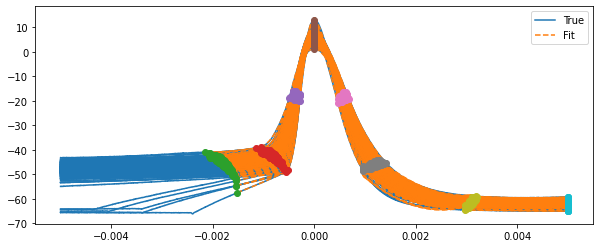

In [5]:
psg.plot()

In [6]:
psg.df_poly.head()

,poly00_c0,poly00_c1,poly00_c2,poly01_c0,poly01_c1,poly01_c2,poly02_c0,poly02_c1,poly02_c2,poly03_c0,...,poly03_c2,poly04_c0,poly04_c1,poly04_c2,poly05_c0,poly05_c1,poly05_c2,poly06_c0,poly06_c1,poly06_c2
0,-45.057117,0.000986,0.000039,-43.067989,0.094022,0.003248,-17.108987,0.732969,-0.005132,9.810201,...,-0.000987,-16.854997,-0.325056,0.000765,-47.048016,-0.082916,0.000129,-60.849958,-0.005595,0.000007
1,-42.796900,-0.001309,0.000048,-41.199057,0.060187,0.002601,-16.395035,0.636255,-0.004093,9.189644,...,-0.001034,-16.338606,-0.302503,0.000651,-46.077389,-0.084669,0.000131,-60.120129,-0.006796,0.000011
2,-42.257892,-0.001008,0.000040,-40.899339,0.026168,0.002303,-16.524248,0.596473,-0.003666,8.549680,...,-0.001112,-16.482108,-0.291533,0.000608,-45.787482,-0.086292,0.000136,-59.872937,-0.005089,0.000007
3,-43.152322,0.002818,0.000038,-41.208653,0.034501,0.002404,-16.447293,0.615461,-0.003866,8.773446,...,-0.001032,-16.698381,-0.296571,0.000643,-45.548660,-0.083797,0.000129,-59.631542,-0.003335,0.000005
4,-44.018510,-0.000870,0.000049,-42.191773,0.076895,0.002851,-16.231664,0.690594,-0.004694,9.986678,...,-0.001269,-16.386068,-0.339348,0.000804,-47.411635,-0.091297,0.000145,-62.321915,-0.004307,0.000007


### Simulation

Next, the polynomial and point indices distributions are used to randomly sampling a multivariate normal distribution. The sampled parameters are then used to simulate spikes with similar statistics and shape as the real data.

This works (kind of) but there needs to be a better way to smooth the simulations at the edges of the polynomials so they are too disjointed.

In [7]:
# Settings
n_sims = 200
poly = psg.df_poly.values
indices = psg.poly_indices
orders = psg.orders

# Stack parameters to compute multivar normal
params = np.column_stack((poly, indices))

mean = np.mean(params, axis=0)
cov = np.cov(params, rowvar=0) / 2 

# Initalize arrays
xs = np.arange(len(psg.spikes[0]))

ys = np.zeros((n_sims, len(xs)))
ys[:] = np.nan

split_ind = sum([i+1 for i in orders])

for n in range(n_sims):
    
    np.random.seed(n)
    
    params = np.random.multivariate_normal(mean, cov)
    
    coeffs = params[:split_ind]
    inds   = params[split_ind:].astype(int)

    starts = inds[:-1]
    ends = inds[1:]

    pos = 0
    
    colors = [f'C{i}' for i in range(len(indices[0])-1)]
    
    for ind in range(len(orders)):

        _coeffs = coeffs[pos:pos+orders[ind]+1][::-1]

        pos += orders[ind]+1

        s = starts[ind]
        e = ends[ind] + 1
        
        ys[n, s:e] =  np.poly1d(_coeffs)(np.arange(e-s))

Text(0.5, 1.0, 'Simulated Spikes')

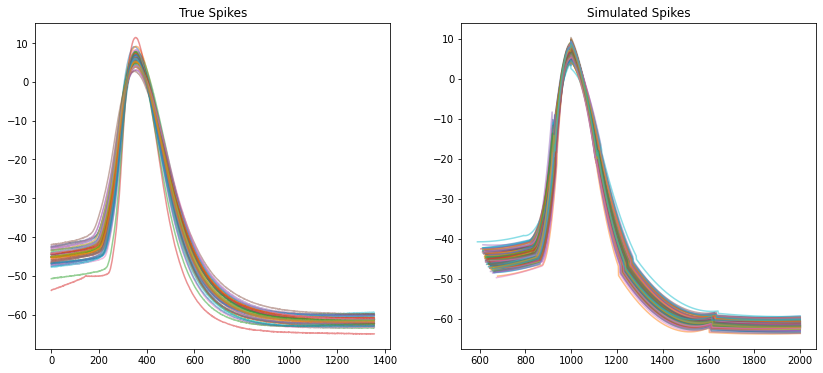

In [8]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 6))

# True
for y in psg.spikes[::4]:
    axes[0].plot(y[646:], alpha=.5)
    
# Simulated

for i in ys:
    axes[1].plot(i, alpha=.5)
    
axes[0].set_title('True Spikes')
axes[1].set_title('Simulated Spikes')